# Null Model Baseline

In [13]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset

In [14]:
df = pd.read_csv("../data/raw/train.csv")
df.head()

,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


## Class distribution

In [15]:
class_counts = df['diagnosis'].value_counts()
print("Class Distribution:\n", class_counts)

Class Distribution:
 diagnosis
0    1805
2     999
1     370
4     295
3     193
Name: count, dtype: int64


## Identify majority class

In [16]:
majority_class = class_counts.idxmax()
print(f"\nMajority Class = {majority_class}")


Majority Class = 0


## Split data

In [17]:
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df['diagnosis'], random_state=42
)

y_true = val_df['diagnosis'].values
y_pred = np.full_like(y_true, fill_value=majority_class)

## Metrics

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
)
import numpy as np



# ------------------------------------
# Compute Metrics
# ------------------------------------
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
bal_acc = balanced_accuracy_score(y_true, y_pred)
grp_acc = compute_grouped_accuracy(y_true, y_pred)

# ------------------------------------
# Print Metrics
# ------------------------------------
print("===== Null Model Metrics =====")
print(f"Accuracy:                   {acc:.4f}")
print(f"Precision (macro):          {prec:.4f}")
print(f"Recall (macro):             {rec:.4f}")
print(f"F1-score (macro):           {f1:.4f}")
print(f"Balanced Accuracy:          {bal_acc:.4f}")
print("================================")

===== Null Model Metrics =====
Accuracy:                   0.4925
Precision (macro):          0.0985
Recall (macro):             0.2000
F1-score (macro):           0.1320
Balanced Accuracy:          0.2000


## Confusion matrix

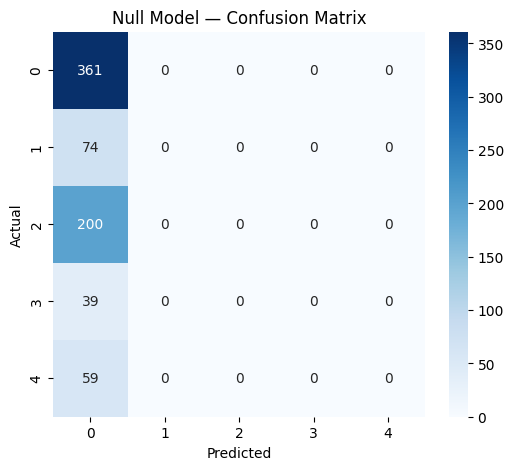

In [9]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_true),
            yticklabels=np.unique(y_true))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Null Model — Confusion Matrix")
plt.show()